In [1]:
import numpy as np 
import pandas as pd 

X11 = np.load("../data/processed/data_matrix2.npy")
X12 = np.load("../data/processed/data_matrix2_reduced.npy")
X13 = np.load("../data/processed/data_matrix2_reduced1.npy")

y = np.load("../data/processed/y.npy")

import joblib
import json

data_matrix_drop_cols = joblib.load("../artifacts/preprocess/data_matrix2_drop_cols.joblib")

In [2]:
import warnings 
warnings.filterwarnings('ignore')

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.utils import to_categorical 
from tensorflow.keras.optimizers import Adam


In [3]:
X11.shape , X12.shape, X13.shape, y.shape, len(data_matrix_drop_cols)

((85849, 101), (85849, 92), (85849, 28), (85849,), 2)

In [4]:
corr_drop_cols = data_matrix_drop_cols['corr_drop_cols']
vif_drop_cols = data_matrix_drop_cols['vif_drop_cols']

In [5]:
len(corr_drop_cols), len(vif_drop_cols )

(9, 73)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [7]:
xtrain ,  xtest ,ytrain ,ytest = train_test_split(X11 , y , test_size = 0.1 , stratify = y , random_state=42)
xtrain.shape , ytrain.shape , xtest.shape , ytest.shape

((77264, 101), (77264,), (8585, 101), (8585,))

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report,
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np





def evaluate_classification_model1(model, X_train, y_train, X_test, y_test):
    """ This function evaluates a classification model using macro averaging for metrics whereever applicable."""
    
    results = {}

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Probabilities for ROC AUC if available (multiclass classification) 
    y_train_prob = model.predict_proba(X_train) if hasattr(model, "predict_proba") else None
    y_test_prob = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    # Calculate metrics helper
    def calc_metrics(y_true, y_pred, y_prob=None):
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0, average='macro')
        recall = recall_score(y_true, y_pred, zero_division=0, average='macro')
        f1 = f1_score(y_true, y_pred, zero_division=0, average='macro')
        roc_auc = (
            roc_auc_score(y_true, y_prob, average='macro', multi_class='ovr')
            if y_prob is not None
            else None
        )
        return accuracy, precision, recall, f1, roc_auc

    train_metrics = calc_metrics(y_train, y_train_pred, y_train_prob)
    test_metrics = calc_metrics(y_test, y_test_pred, y_test_prob)

    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

    # Print metrics
    print("Training Metrics:")
    for name, value in zip(metric_names, train_metrics):
        if value is not None:
            print(f"{name}: {value:.4f}")

    print("\nTesting Metrics:")
    for name, value in zip(metric_names, test_metrics):
        if value is not None:
            print(f"{name}: {value:.4f}")

    # Detailed classification report for test
    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    # Confusion matrix plot for test data
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix (Test)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Plot ROC curves per class for multiclass data (One-vs-Rest)
    if y_test_prob is not None:
        classes = np.unique(y_test)
        y_test_binarized = label_binarize(y_test, classes=classes)
        n_classes = y_test_binarized.shape[1]

        plt.figure(figsize=(8, 6))

        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_test_prob[:, i])
            roc_auc = roc_auc_score(y_test_binarized[:, i], y_test_prob[:, i])
            plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")

        plt.plot([0, 1], [0, 1], "k--", label="Random Chance")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Multiclass ROC Curve (One-vs-Rest)")
        plt.legend()
        plt.grid(True)
        plt.show()

    return {"train_metrics": train_metrics, "test_metrics": test_metrics}


In [43]:
lr = LogisticRegression(random_state = 42)
lr.fit(xtrain,ytrain)

print(lr.score(xtrain,ytrain))
print(lr.score(xtest,ytest))

0.6982553323669497
0.6985439720442632


Training Metrics:
Accuracy: 0.6983
Precision: 0.2501
Recall: 0.2129
F1 Score: 0.1898
ROC AUC: 0.6016

Testing Metrics:
Accuracy: 0.6985
Precision: 0.2564
Recall: 0.2132
F1 Score: 0.1903
ROC AUC: 0.5972

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.58      0.07      0.13      1121
           2       0.00      0.00      0.00       128
           3       0.00      0.00      0.00       256
           4       0.00      0.00      0.00      1121
           5       0.70      0.99      0.82      5959

    accuracy                           0.70      8585
   macro avg       0.26      0.21      0.19      8585
weighted avg       0.56      0.70      0.59      8585



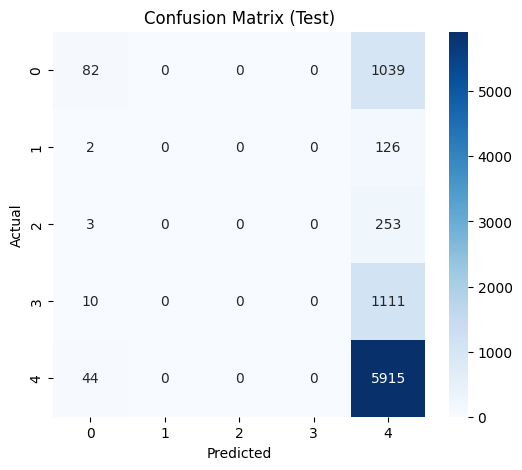

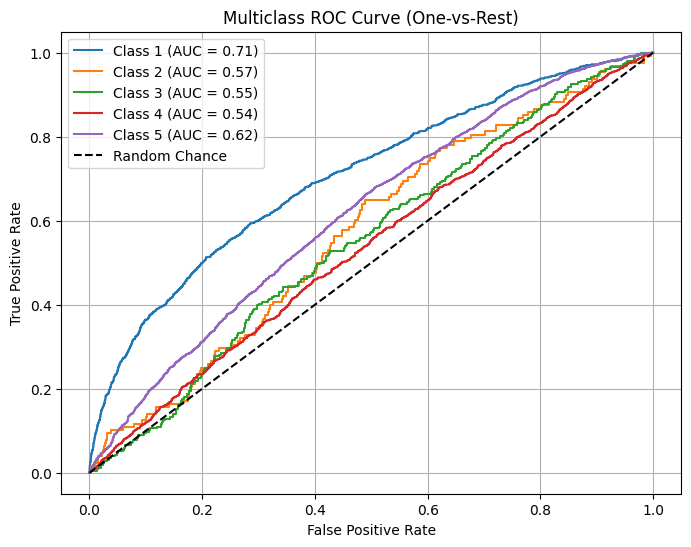

In [44]:
lr_train_metrics, lr_test_metrics = evaluate_classification_model1(lr, xtrain, ytrain, xtest, ytest)

In [42]:

lr1 = LogisticRegression(max_iter=1000 , random_state = 42)
lr1.fit(xtrain,ytrain)

print(lr1.score(xtrain,ytrain))
print(lr1.score(xtest,ytest))

0.715365500103541
0.7150844496214327


d:\Deep Learning Projects\Deep CSAT - Ecommerce Customer Satisfaction Score Prediction\csat_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Metrics:
Accuracy: 0.7154
Precision: 0.5849
Recall: 0.7154
F1 Score: 0.6242
ROC AUC: 0.6800

Testing Metrics:
Accuracy: 0.7151
Precision: 0.5833
Recall: 0.7151
F1 Score: 0.6242
ROC AUC: 0.6818

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.64      0.26      0.37      1121
           2       0.00      0.00      0.00       128
           3       0.00      0.00      0.00       256
           4       0.00      0.00      0.00      1121
           5       0.72      0.98      0.83      5959

    accuracy                           0.72      8585
   macro avg       0.27      0.25      0.24      8585
weighted avg       0.58      0.72      0.62      8585



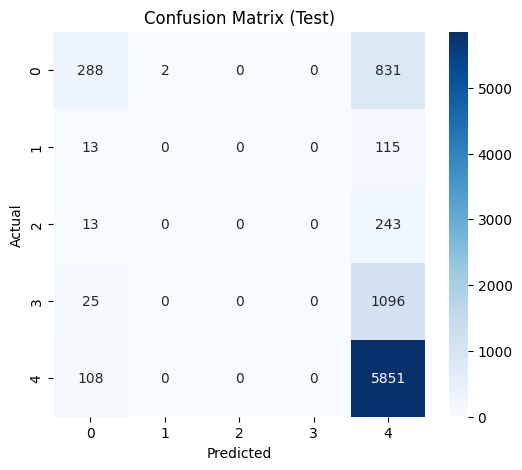

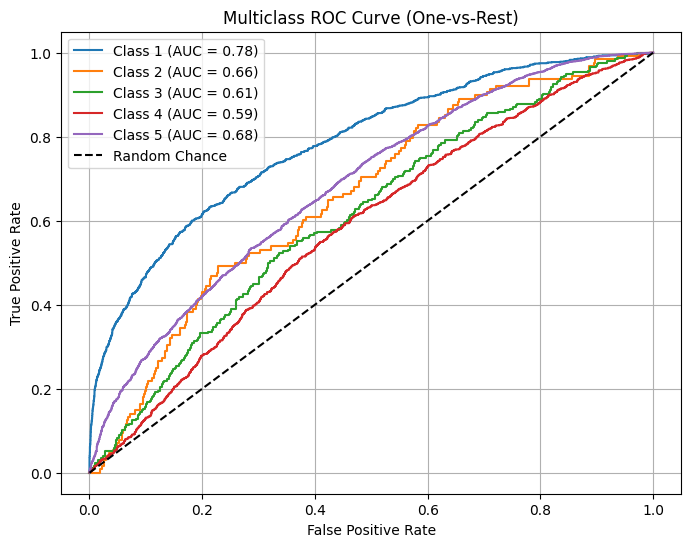

{'train_metrics': (0.715365500103541,
  0.5849183009508585,
  0.715365500103541,
  0.6241877020411264,
  0.6800202312312298),
 'test_metrics': (0.7150844496214327,
  0.5833042121016129,
  0.7150844496214327,
  0.6242396804394158,
  0.6818103927743444)}

In [ ]:
lr1_train_metrics, lr1_test_metrics = evaluate_classification_model1(lr1, xtrain, ytrain, xtest, ytest)

# Lower precision_score indicates higher cases of False Positives.Since it is multiclass classification , it indicates that some classes are being misclassified as other classes.

# Higher recall_score indicates that most of the actual positive cases are being identified correctly.In multiclass classification , it indicates that most of the records/entries are identified correctly.But here since the data in imbalanced , it tells that the model is biased towards the majority class and is not performing well on minority classes.

# ROC AUC = 0.68 means that the model has a 68% chance of distinguishing between classes, which is better than random guessing but indicates room for improvement.

# Classification report precision is 0 for 2 , 3 , 4 indicates that the model is not predicting any instances of these classes correctly, likely due to class imbalance or insufficient training data for these classes.It indicates that TP = 0 for these classes. 
# Similarly recall is also 0 for these classes indicating that the model is not able to identify any actual instances of these classes correctly.
# Overall , the model performs well on the majority class (class 5) and the class 1 , but struggles with minority classes (2, 3, 4) likely due to class imbalance.



In [50]:

lr2 = LogisticRegression(max_iter=1000 , class_weight='balanced', random_state=42)
lr2.fit(xtrain,ytrain)

print(lr2.score(xtrain,ytrain))
print(lr2.score(xtest,ytest))

0.35257040795195693
0.3546884100174723


d:\Deep Learning Projects\Deep CSAT - Ecommerce Customer Satisfaction Score Prediction\csat_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Metrics:
Accuracy: 0.3526
Precision: 0.6513
Recall: 0.3526
F1 Score: 0.4235
ROC AUC: 0.6688

Testing Metrics:
Accuracy: 0.3547
Precision: 0.6522
Recall: 0.3547
F1 Score: 0.4268
ROC AUC: 0.6703

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.38      0.48      0.42      1121
           2       0.02      0.18      0.03       128
           3       0.04      0.16      0.06       256
           4       0.16      0.33      0.21      1121
           5       0.84      0.35      0.49      5959

    accuracy                           0.35      8585
   macro avg       0.29      0.30      0.24      8585
weighted avg       0.65      0.35      0.43      8585



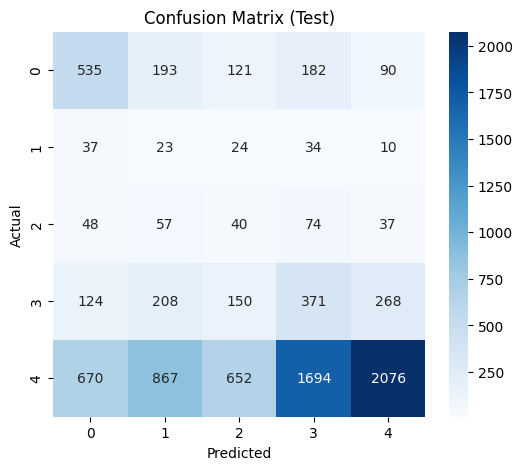

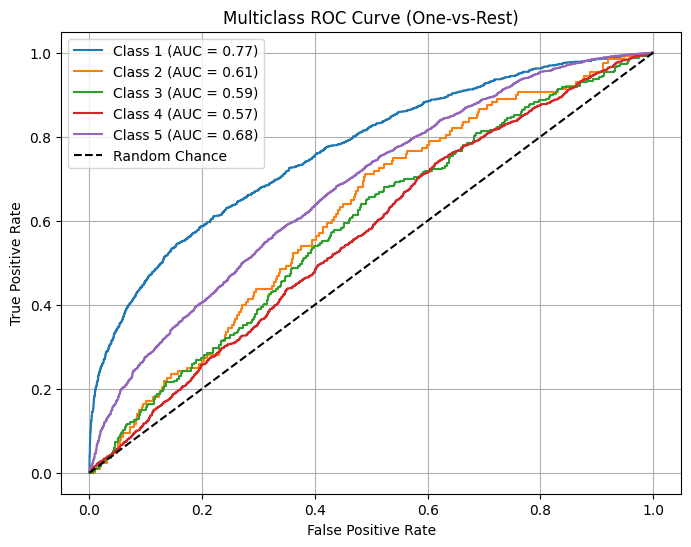

{'train_metrics': (0.35257040795195693,
  0.6512694363428556,
  0.35257040795195693,
  0.4234849099154998,
  0.6687855065156398),
 'test_metrics': (0.3546884100174723,
  0.652247854276944,
  0.3546884100174723,
  0.4268388002286164,
  0.6702834268218846)}

In [ ]:
lr2_train_metrics, lr2_test_metrics = evaluate_classification_model1(lr2, xtrain, ytrain, xtest, ytest)

Creating RF , XGB , DNN for this dataset 

In [52]:
rf1 = RandomForestClassifier(random_state = 42,n_jobs=-1 , n_estimators=200 , max_depth=10)

rf1.fit(xtrain,ytrain)

print(rf1.score(xtrain,ytrain))
print(rf1.score(xtest,ytest))

0.7191706357423897
0.7165987186953989


Training Metrics:
Accuracy: 0.7192
Precision: 0.3060
Recall: 0.2418
F1 Score: 0.2341
ROC AUC: 0.7553

Testing Metrics:
Accuracy: 0.7166
Precision: 0.2989
Recall: 0.2394
F1 Score: 0.2306
ROC AUC: 0.6788

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.78      0.20      0.32      1121
           2       0.00      0.00      0.00       128
           3       0.00      0.00      0.00       256
           4       0.00      0.00      0.00      1121
           5       0.71      0.99      0.83      5959

    accuracy                           0.72      8585
   macro avg       0.30      0.24      0.23      8585
weighted avg       0.60      0.72      0.62      8585



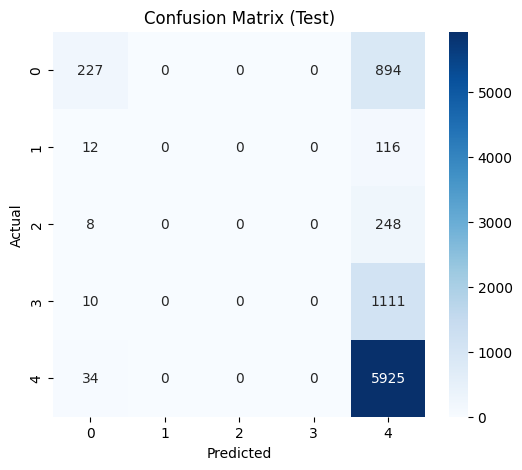

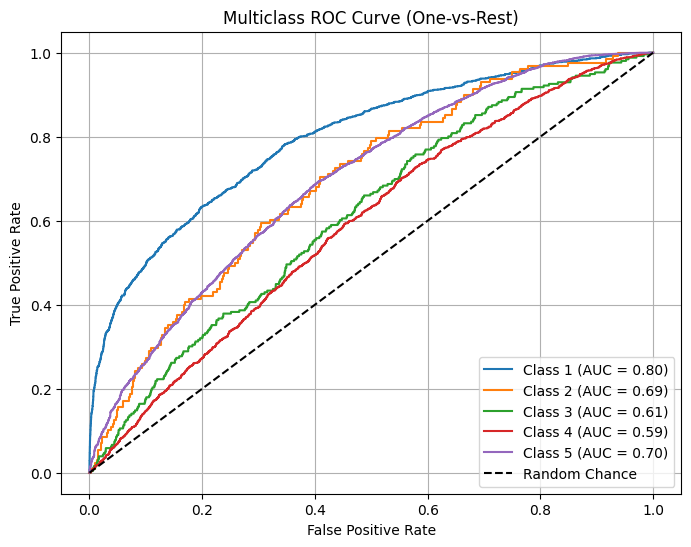

{'train_metrics': (0.7191706357423897,
  0.3059660877644368,
  0.24180128629985206,
  0.23411505402069865,
  0.7553159868625879),
 'test_metrics': (0.7165987186953989,
  0.2988881127167654,
  0.2393584229074112,
  0.23058673200155266,
  0.6787553029590384)}

In [ ]:
rf1_train_metrics, rf1_test_metrics = evaluate_classification_model1(rf1, xtrain , ytrain , xtest , ytest)

In [54]:
rf2 = RandomForestClassifier(random_state = 42,n_jobs=-1 , n_estimators=200 , max_depth=10 , class_weight='balanced')

rf2.fit(xtrain,ytrain)

print(rf2.score(xtrain,ytrain))
print(rf2.score(xtest,ytest))

0.4649383930420377
0.43249854397204424


Training Metrics:
Accuracy: 0.4649
Precision: 0.3440
Recall: 0.4773
F1 Score: 0.3432
ROC AUC: 0.7778

Testing Metrics:
Accuracy: 0.4325
Precision: 0.2965
Recall: 0.3250
F1 Score: 0.2769
ROC AUC: 0.6565

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.41      0.52      0.46      1121
           2       0.03      0.14      0.05       128
           3       0.05      0.15      0.07       256
           4       0.17      0.37      0.23      1121
           5       0.84      0.45      0.58      5959

    accuracy                           0.43      8585
   macro avg       0.30      0.32      0.28      8585
weighted avg       0.66      0.43      0.50      8585



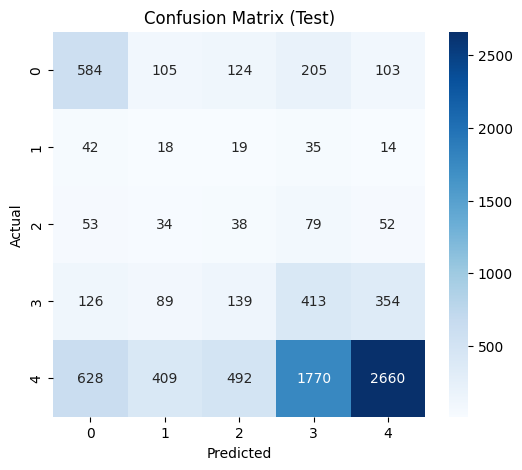

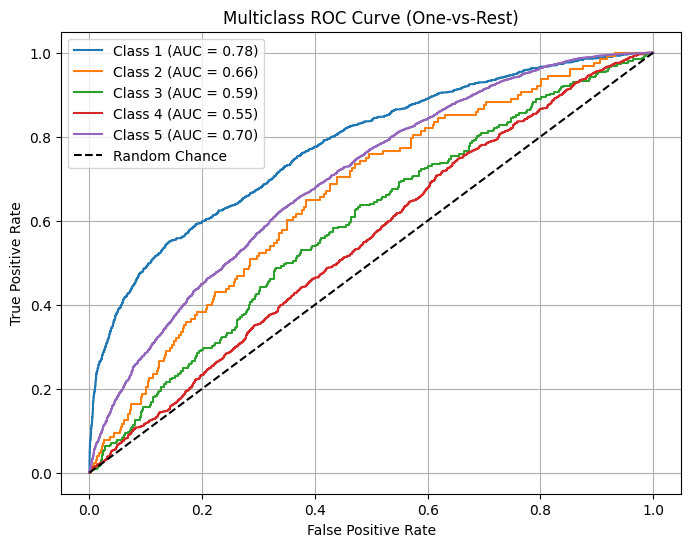

{'train_metrics': (0.4649383930420377,
  0.3440114510103648,
  0.4772933408023615,
  0.34315879314469094,
  0.7778042650732502),
 'test_metrics': (0.43249854397204424,
  0.29651462573261733,
  0.3249661199115005,
  0.27687546390583534,
  0.6565057295953134)}

In [ ]:
rf2_train_metrics, rf2_test_metrics=evaluate_classification_model1(rf2, xtrain , ytrain , xtest , ytest)

In [56]:
rf3 = RandomForestClassifier(random_state = 42,n_jobs=-1 , n_estimators=200 , max_depth=20 , class_weight="balanced")

rf3.fit(xtrain,ytrain)

print(rf3.score(xtrain,ytrain))
print(rf3.score(xtest,ytest))

0.9337078069993787
0.6656959813628421


Training Metrics:
Accuracy: 0.9337
Precision: 0.8839
Recall: 0.9362
F1 Score: 0.9076
ROC AUC: 0.9822

Testing Metrics:
Accuracy: 0.6657
Precision: 0.2971
Recall: 0.2810
F1 Score: 0.2845
ROC AUC: 0.6419

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.51      0.42      0.46      1121
           2       0.00      0.00      0.00       128
           3       0.05      0.02      0.03       256
           4       0.18      0.11      0.13      1121
           5       0.75      0.86      0.80      5959

    accuracy                           0.67      8585
   macro avg       0.30      0.28      0.28      8585
weighted avg       0.61      0.67      0.63      8585



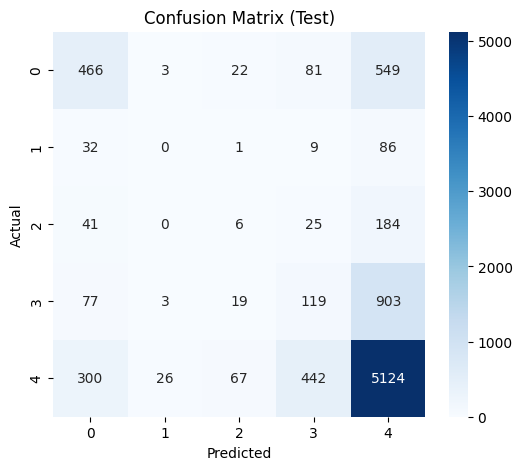

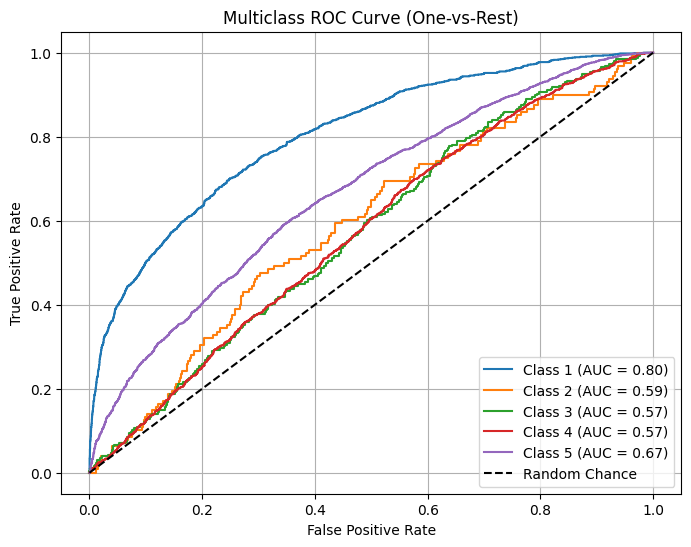

{'train_metrics': (0.9337078069993787,
  0.8838641880792277,
  0.9361734199249636,
  0.9075527544299089,
  0.9822165583187841),
 'test_metrics': (0.6656959813628421,
  0.2970818596249837,
  0.2810337608526686,
  0.2845271887000713,
  0.6418510073883305)}

In [ ]:
rf3_train_metrics, rf3_test_metrics = evaluate_classification_model1(rf3, xtrain, ytrain, xtest, ytest)

In [62]:
# Trying XGB

from pandas.core.common import random_state
from sklearn.utils import class_weight
import numpy as np

classes = np.unique(ytrain-1)
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=classes, y=ytrain-1)
weight_dict = dict(zip(classes, class_weights))
sample_weights = np.array([weight_dict[c] for c in ytrain-1])

xgb1 = XGBClassifier(random_state=42 )
xgb1.fit(xtrain, ytrain-1, sample_weight=sample_weights)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [63]:
xgb1.score(xtrain,ytrain-1) , xgb1.score(xtest,ytest-1)

(0.5246816110996065, 0.43401281304601047)

Training Metrics:
Accuracy: 0.5247
Precision: 0.3950
Recall: 0.6326
F1 Score: 0.4110
ROC AUC: 0.8462

Testing Metrics:
Accuracy: 0.4340
Precision: 0.2879
Recall: 0.3063
F1 Score: 0.2684
ROC AUC: 0.6446

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.39      0.48      0.43      1121
           1       0.02      0.13      0.04       128
           2       0.04      0.14      0.06       256
           3       0.17      0.31      0.21      1121
           4       0.82      0.47      0.60      5959

    accuracy                           0.43      8585
   macro avg       0.29      0.31      0.27      8585
weighted avg       0.64      0.43      0.50      8585



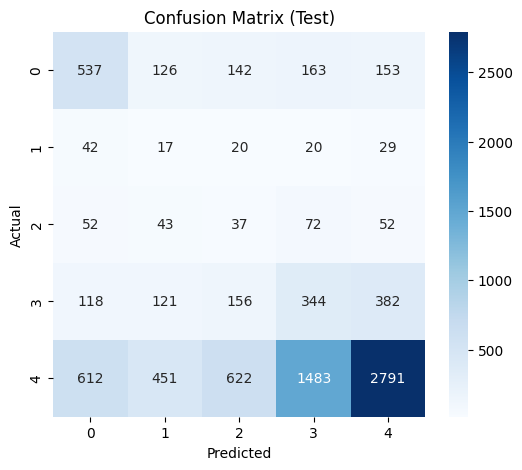

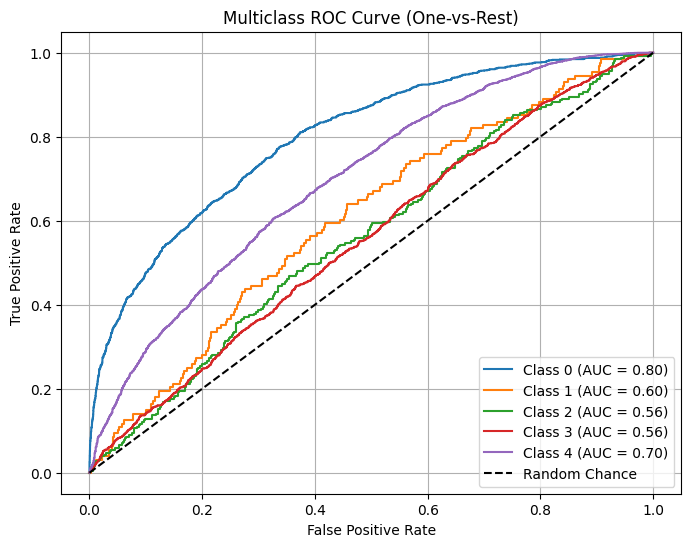

{'train_metrics': (0.5246816110996065,
  0.3949672820927394,
  0.6325733531917316,
  0.410979461260219,
  0.8461922414591283),
 'test_metrics': (0.43401281304601047,
  0.2878565627498162,
  0.3063232734541295,
  0.268378119217748,
  0.6446415848085616)}

In [ ]:
xgb1_train_metrics, xgb1_test_metrics=evaluate_classification_model1(xgb1, xtrain, ytrain-1, xtest, ytest-1)

Now trying ann models

In [9]:
import tensorflow as tf
tf.__version__

'2.20.0-rc0'

In [10]:
# layers : Dense , Dropout , BatchNormalization , Flatten 
# models : Sequential , Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.utils import to_categorical 
from tensorflow.keras.optimizers import Adam


In [78]:
# order of execution : Create the model -> Compile the model -> Fit the model -> Evaluate the model


# Model creation
classes = np.unique(y-1)
n_classes = len(classes)

ann1 = Sequential()
ann1.add(Input(shape=(xtrain.shape[1],)))
ann1.add(Dense(128, activation='relu',))
ann1.add(Dense(64 , activation = 'relu'))
ann1.add(Dense(n_classes) )

ann1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,637 (84.52 KB)

 Trainable params: 21,637 (84.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Model_compilation

ann1.compile(optimizer=Adam(learning_rate=0.01), loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [81]:
# Fit the model 

history = ann1.fit(xtrain, ytrain-1, validation_data=(xtest, ytest-1), epochs=100, batch_size=32)    

Epoch 1/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6899 - loss: 1.2105 - val_accuracy: 0.6945 - val_loss: 0.9508
Epoch 2/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6952 - loss: 0.9479 - val_accuracy: 0.6948 - val_loss: 0.9443
Epoch 3/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 2s 982us/step - accuracy: 0.6970 - loss: 0.9491 - val_accuracy: 0.6941 - val_loss: 0.9526
Epoch 4/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 2s 977us/step - accuracy: 0.6941 - loss: 0.9770 - val_accuracy: 0.6941 - val_loss: 0.9537
Epoch 5/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 2s 960us/step - accuracy: 0.6941 - loss: 0.9533 - val_accuracy: 0.6941 - val_loss: 0.9527
Epoch 6/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 2s 959us/step - accuracy: 0.6941 - loss: 0.9532 - val_accuracy: 0.6941 - val_loss: 0.9529
Epoch 7/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 2s 956us/step - accuracy: 0.6938 - loss: 0.9592 - val_accuracy: 0.6941 - val_loss: 0.9527
Epoch 8/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 2s 965us/step - accuracy: 0.69

In [82]:
ann1.evaluate(xtest , ytest-1)

269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 816us/step - accuracy: 0.6941 - loss: 0.9531


[0.953141450881958, 0.6941176652908325]

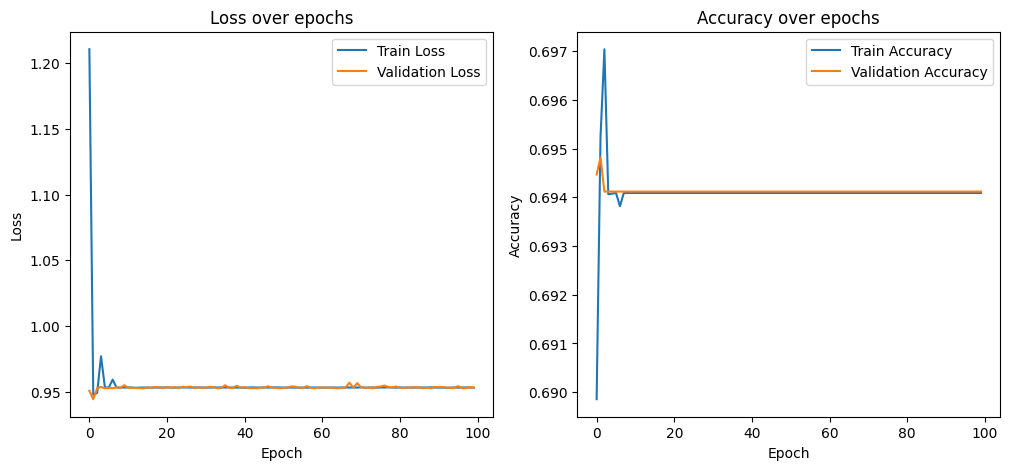

In [83]:

# Plot Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy (or another metric you used, e.g. precision)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


The graphs shows that the model reached its peak performance quite early in the epochs and thereafter no further improvement happened on loss decrease and accuracy increase . The accuracy became stagnant at 0.694 for both training and validation sets . The models shows not overfitting.

In [22]:
# from sklearn.metrics import f1_score
# import numpy as np
def metrics_eval(model, X_test, y_test):
   
    y_pred_prob = model.predict(X_test)  # shape: (n_samples, n_classes)
    y_pred = np.argmax(y_pred_prob, axis=1)  # class with highest probability

    f1 = f1_score(y_test, y_pred, average='macro')  # or 'weighted', 'micro' based on your needs
    print(f"F1 Score : {f1:.4f}")

    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")


In [85]:

metrics_eval(ann1, xtest, ytest-1)



269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 642us/step
F1 Score : 0.1639
Precision: 0.1388
Recall: 0.2000


ANN model2 : Making it more deeper and there complex that may be able to capture more underlying patterns in the data to reduce the bias occuring in the model training

In [92]:
# Model creation
classes = np.unique(y-1)
n_classes = len(classes)

ann2 = Sequential()
ann2.add(Input(shape=(xtrain.shape[1],)))
ann2.add(Dense(256, activation='relu',))
ann2.add(Dense(128, activation='relu',))
ann2.add(Dense(64 , activation = 'relu'))
ann2.add(Dense(n_classes) )

ann2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │        26,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,589 (264.02 KB)

 Trainable params: 67,589 (264.02 KB)

 Non-trainable params: 0 (0.00 B)

In [93]:
# Model_compilation

ann2.compile(optimizer=Adam(learning_rate=0.01), loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])


In [94]:



# Fit the model 

history1 = ann1.fit(xtrain, ytrain-1, validation_data=(xtest, ytest-1), epochs=50, batch_size=32)    





Epoch 1/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6941 - loss: 0.9533 - val_accuracy: 0.6941 - val_loss: 0.9528
Epoch 2/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6941 - loss: 0.9533 - val_accuracy: 0.6941 - val_loss: 0.9533
Epoch 3/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6941 - loss: 0.9533 - val_accuracy: 0.6941 - val_loss: 0.9528
Epoch 4/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6941 - loss: 0.9533 - val_accuracy: 0.6941 - val_loss: 0.9526
Epoch 5/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6941 - loss: 0.9531 - val_accuracy: 0.6941 - val_loss: 0.9534
Epoch 6/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6941 - loss: 0.9533 - val_accuracy: 0.6941 - val_loss: 0.9531
Epoch 7/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6941 - loss: 0.9532 - val_accuracy: 0.6941 - val_loss: 0.9530
Epoch 8/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6941 - loss: 0.9533 - 

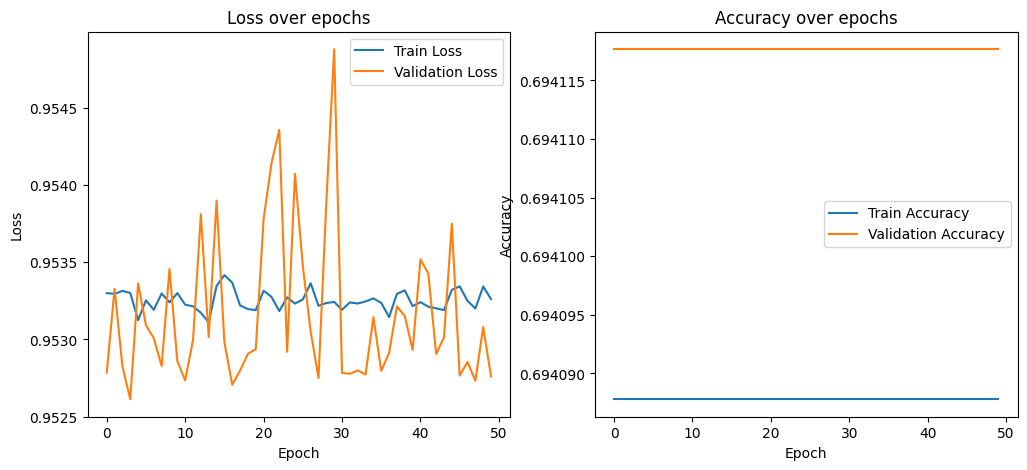

In [96]:
# Plot Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy (or another metric you used, e.g. precision)
plt.subplot(1, 2, 2)
plt.plot(history1.history['accuracy'], label='Train Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [97]:
#Evaluate metrics : Precision , Recall , F1 score 

metrics_eval(ann2, xtest, ytest-1)

269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
F1 Score : 0.0628
Precision: 0.1731
Recall: 0.2005


Third ANN model : May be just tweaking the learning rate and increasing the model complexity using addition of hidden layers wont be enough . It can be seen that model is plateauing around 69 percent accuracy and remains thereafter . This is sign of model trapping in the local minima .. Data imbalance is also a big problem for the models .  But it is my concern that if i use artificially created data using techniques like smote , it will add more bias to model and that can make the model even more underfit .But we will check each and every options .

In [ ]:
# ann model creation approach : create model architecture (number of hidden layers , dropout layers , batch normalization layers , activation for each layer , Input Shape and Output shape ) -> compile the model ( loss , optimizer , metrics to be evaluated during training epochs) -> fit the model (give the data to train on and there capture the relationship between x and y) -> model evaluation ( visualization of metrics and plot the performances on various aspects )

Ann model 3

In [11]:
xtrain.shape , ytrain.shape , xtest.shape , ytest.shape

((77264, 101), (77264,), (8585, 101), (8585,))

In [12]:
np.unique(ytrain)

array([1, 2, 3, 4, 5])

In [15]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(ytrain-1)
n_classes = len(classes)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=ytrain-1
)

# Put weights in dict form required by fit
class_weight_dict = dict(zip(classes, class_weights))


In [16]:
class_weight_dict

{np.int64(0): np.float64(1.5311930241775664),
 np.int64(1): np.float64(13.390641247833623),
 np.int64(2): np.float64(6.715688830943068),
 np.int64(3): np.float64(1.5316483298642085),
 np.int64(4): np.float64(0.28814798239725514)}

In [17]:
# 6 layered ann model 

ann3 = Sequential()
ann3.add(Input(shape=(xtrain.shape[1],)))
ann3.add(Dense(512, activation='relu',))
ann3.add(Dense(512, activation='relu',))
ann3.add(Dense(256, activation='relu',))
ann3.add(Dense(128, activation='relu',))
ann3.add(Dense(64 , activation = 'relu'))
ann3.add(Dense(n_classes))

In [18]:
ann3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        52,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 487,685 (1.86 MB)

 Trainable params: 487,685 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Model_compilation

ann3.compile(optimizer=Adam(learning_rate=0.01), loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [20]:

# Fit the model 

history3 = ann3.fit(xtrain, ytrain-1, validation_data=(xtest, ytest-1), epochs=50, batch_size=32 , class_weight=class_weight_dict)


Epoch 1/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.1239 - loss: 2.0569 - val_accuracy: 0.1306 - val_loss: 1.6185
Epoch 2/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.1441 - loss: 1.6113 - val_accuracy: 0.0149 - val_loss: 1.6445
Epoch 3/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.1420 - loss: 1.6111 - val_accuracy: 0.0149 - val_loss: 1.6889
Epoch 4/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.1234 - loss: 1.6118 - val_accuracy: 0.0149 - val_loss: 1.6223
Epoch 5/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.1397 - loss: 1.6111 - val_accuracy: 0.0298 - val_loss: 1.6203
Epoch 6/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.1426 - loss: 1.6113 - val_accuracy: 0.6941 - val_loss: 1.5634
Epoch 7/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.1617 - loss: 1.6117 - val_accuracy: 0.6941 - val_loss: 1.5938
Epoch 8/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.1630 - loss: 1.6118

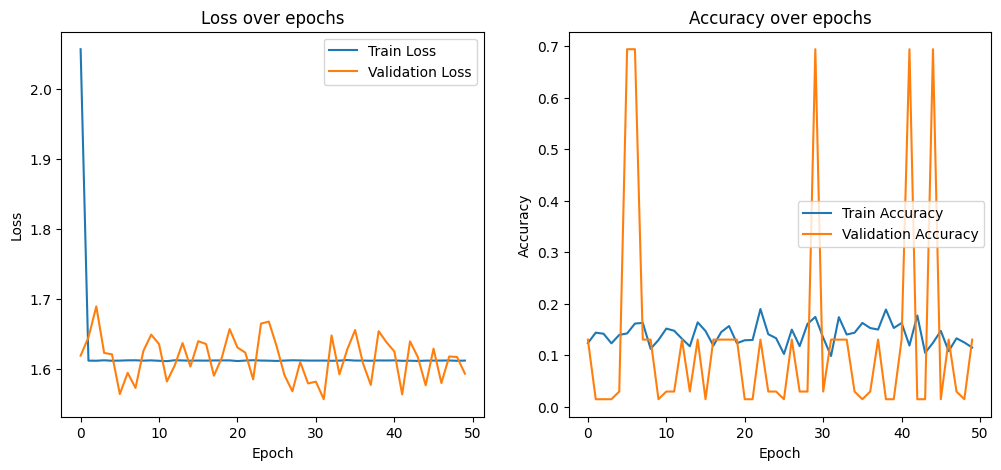

In [21]:
# Plot Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history3.history['loss'], label='Train Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy (or another metric you used, e.g. precision)
plt.subplot(1, 2, 2)
plt.plot(history3.history['accuracy'], label='Train Accuracy')
plt.plot(history3.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [23]:
metrics_eval(ann3, xtest, ytest-1)

269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
F1 Score : 0.0462
Precision: 0.0261
Recall: 0.2000


In [39]:
metrics_eval(ann3, xtrain, ytrain-1)

2415/2415 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
F1 Score : 0.0462
Precision: 0.0261
Recall: 0.2000


Same 6 layered ann model along with learning rate scheduler

In [30]:
ann4 = Sequential()
ann4.add(Input(shape=(xtrain.shape[1],)))
ann4.add(Dense(512, activation='relu',))
ann4.add(Dense(512, activation='relu',))
ann4.add(Dense(256, activation='relu',))
ann4.add(Dense(128, activation='relu',))
ann4.add(Dense(64 , activation = 'relu',))
ann4.add(Dense(n_classes))

In [31]:
ann4.summary() 

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │        52,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 487,685 (1.86 MB)

 Trainable params: 487,685 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Model_compilation

ann4.compile(optimizer=Adam(learning_rate=0.01), loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [33]:

from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',     # Metric to monitor
    factor=0.2,             # Reduce LR by multiplying with this factor
    patience=5,             # Wait for these many epochs before reducing
    min_lr=1e-6,            # Minimum LR after which no further reduction
    verbose=1               # Prints update messages
)


In [34]:

# Fit the model 

history4 = ann4.fit(xtrain, ytrain-1, validation_data=(xtest, ytest-1), epochs=50, batch_size=32 , class_weight=class_weight_dict , callbacks=[reduce_lr])


Epoch 1/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.1389 - loss: 2.3296 - val_accuracy: 0.0149 - val_loss: 1.6582 - learning_rate: 0.0100
Epoch 2/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.1504 - loss: 1.7649 - val_accuracy: 0.1306 - val_loss: 1.5883 - learning_rate: 0.0100
Epoch 3/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.1347 - loss: 1.6112 - val_accuracy: 0.1306 - val_loss: 1.5892 - learning_rate: 0.0100
Epoch 4/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.1156 - loss: 1.6111 - val_accuracy: 0.0298 - val_loss: 1.6041 - learning_rate: 0.0100
Epoch 5/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.1505 - loss: 1.6104 - val_accuracy: 0.0298 - val_loss: 1.6288 - learning_rate: 0.0100
Epoch 6/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.1600 - loss: 1.6117 - val_accuracy: 0.1306 - val_loss: 1.5788 - learning_rate: 0.0100
Epoch 7/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.1341 - 

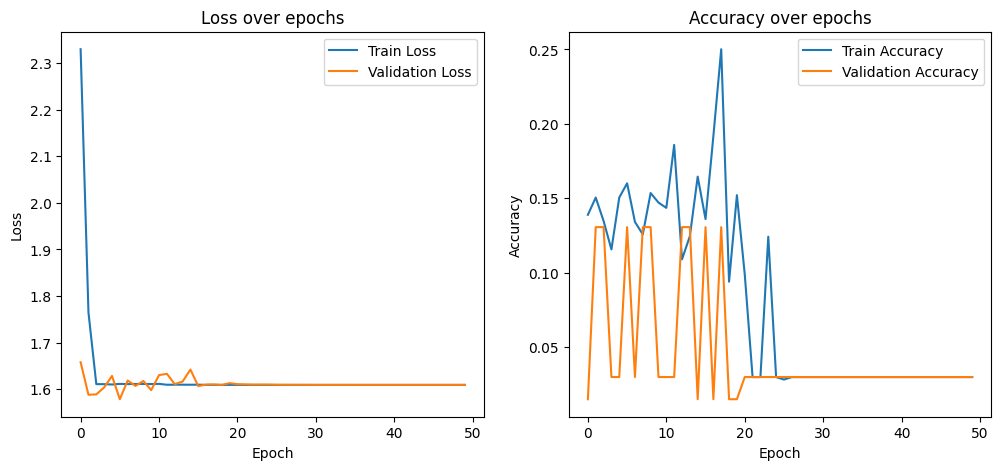

In [35]:
# Plot Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history4.history['loss'], label='Train Loss')
plt.plot(history4.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy (or another metric you used, e.g. precision)
plt.subplot(1, 2, 2)
plt.plot(history4.history['accuracy'], label='Train Accuracy')
plt.plot(history4.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [36]:
metrics_eval(ann4, xtest, ytest-1)

269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
F1 Score : 0.0116
Precision: 0.0060
Recall: 0.2000


In [37]:
metrics_eval(ann4, xtrain, ytrain-1)

2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
F1 Score : 0.0116
Precision: 0.0060
Recall: 0.2000


Despite employing various artificial neural network (ANN) models with different architectures and training approaches, the evaluation metrics indicate suboptimal performance. This can likely be attributed to constraints in dataset information and intrinsic data quality issues that cannot be remedied, as they are inherent to the provided data. While a more informative dataset may have allowed the models to capture richer relationships and mitigate bias—thus improving overall performance—such improvements are not feasible in the current context.

It has been observed that less complex models tend to yield better metric results. Nonetheless, even these models demonstrate a significant inability to accurately classify rare customer satisfaction (csat) categories, specifically scores of 2, 3, and 4; their predictive ability for these categories often remains very low or even negligible.

Given these limitations, the approach will shift to reframing the multiclass classification problem into a binary classification task. This transformation draws upon common human judgment practices, where:

Satisfaction ratings (csat_score) of 1 and 2 will be encoded as "not satisfactory" (label 0).

Satisfaction ratings of 3, 4, and 5 will be encoded as "satisfactory" (label 1).

This binary categorization is expected to enable more robust model performance and result in higher classification effectiveness, given the available data.

In [46]:
# y binarized

def binarize(y):
    return np.where(y >= 3, 1, 0)


y_binarized = binarize(y)

In [49]:
xtrain1 ,  xtest1 ,ytrain1 ,ytest1 = train_test_split(X11 , y_binarized , test_size = 0.1 , stratify = y_binarized , random_state=42)
xtrain1.shape , ytrain1.shape , xtest1.shape , ytest1.shape

((77264, 101), (77264,), (8585, 101), (8585,))

In [50]:
np.unique(y_binarized , return_counts=True)

# The issue of class imbalance still exists even after binarization.

(array([0, 1]), array([12495, 73354]))

In [52]:
# evaluation for binary classification


def evaluate_classification_model_binary(model, X_train, y_train, X_test, y_test):
    """Evaluate a binary classification model with standard metrics and plots."""

    results = {}

    # Predictions (binary outputs)
    y_train_pred = (model.predict(X_train) > 0.5).astype(int) if hasattr(model, "predict") else model.predict(X_train)
    y_test_pred = (model.predict(X_test) > 0.5).astype(int) if hasattr(model, "predict") else model.predict(X_test)

    # Probabilities for ROC AUC
    if hasattr(model, "predict_proba"):
        y_train_prob = model.predict_proba(X_train)[:, 1]
        y_test_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "predict"):
        # Some models output probabilities directly in predict()
        y_train_prob = model.predict(X_train).ravel()
        y_test_prob = model.predict(X_test).ravel()
    else:
        y_train_prob = None
        y_test_prob = None

    # Calculate metrics helper
    def calc_metrics(y_true, y_pred, y_prob=None):
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        roc_auc = roc_auc_score(y_true, y_prob) if y_prob is not None else None
        return accuracy, precision, recall, f1, roc_auc

    train_metrics = calc_metrics(y_train, y_train_pred, y_train_prob)
    test_metrics = calc_metrics(y_test, y_test_pred, y_test_prob)

    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

    # Print metrics
    print("Training Metrics:")
    for name, value in zip(metric_names, train_metrics):
        if value is not None:
            print(f"{name}: {value:.4f}")

    print("\nTesting Metrics:")
    for name, value in zip(metric_names, test_metrics):
        if value is not None:
            print(f"{name}: {value:.4f}")

    # Detailed classification report for test
    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    # Confusion matrix plot for test data
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Confusion Matrix (Test)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Plot ROC curve for binary
    if y_test_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_test_prob)
        roc_auc = roc_auc_score(y_test, y_test_prob)

        plt.figure(figsize=(7, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()

    return {"train_metrics": train_metrics, "test_metrics": test_metrics}


Model creation for binary classification


In [53]:
lr3 = LogisticRegression(max_iter=500 , class_weight='balanced', random_state=42)
lr3.fit(xtrain1,ytrain1)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


Training Metrics:
Accuracy: 0.7525
Precision: 0.9248
Recall: 0.7732
F1 Score: 0.8422
ROC AUC: 0.7797

Testing Metrics:
Accuracy: 0.7471
Precision: 0.9241
Recall: 0.7670
F1 Score: 0.8383
ROC AUC: 0.7753

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.32      0.63      0.42      1250
           1       0.92      0.77      0.84      7335

    accuracy                           0.75      8585
   macro avg       0.62      0.70      0.63      8585
weighted avg       0.84      0.75      0.78      8585



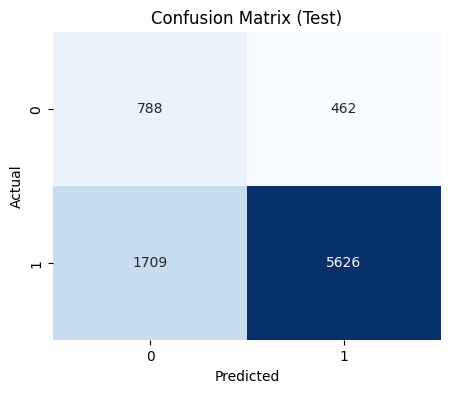

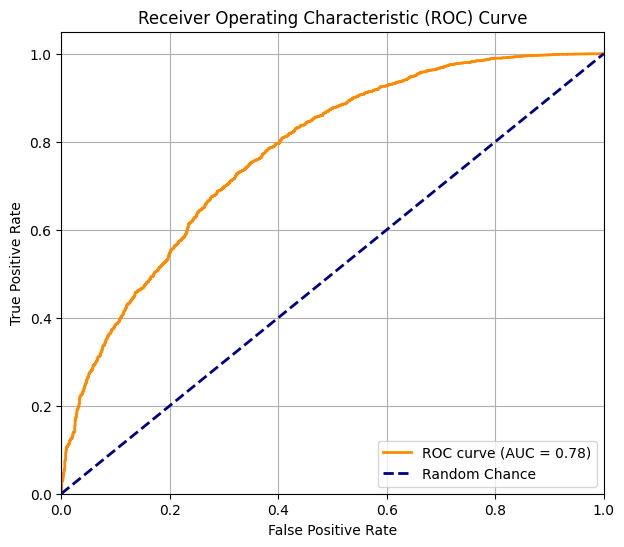

In [55]:
lr3_train_metrics , lr3_test_metrics = evaluate_classification_model_binary(lr3 , xtrain1 , ytrain1 , xtest1 , ytest1)

Training Metrics:
Accuracy: 0.7508
Precision: 0.9253
Recall: 0.7706
F1 Score: 0.8409
ROC AUC: 0.7804

Testing Metrics:
Accuracy: 0.7462
Precision: 0.9253
Recall: 0.7647
F1 Score: 0.8374
ROC AUC: 0.7762

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.32      0.64      0.42      1250
           1       0.93      0.76      0.84      7335

    accuracy                           0.75      8585
   macro avg       0.62      0.70      0.63      8585
weighted avg       0.84      0.75      0.78      8585



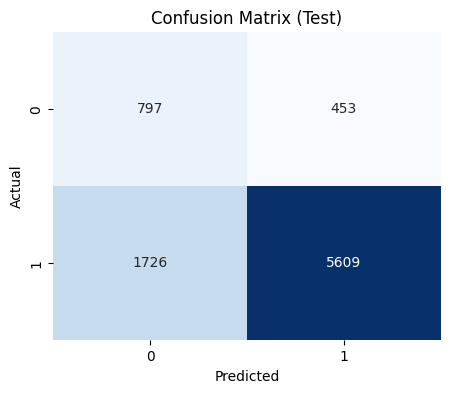

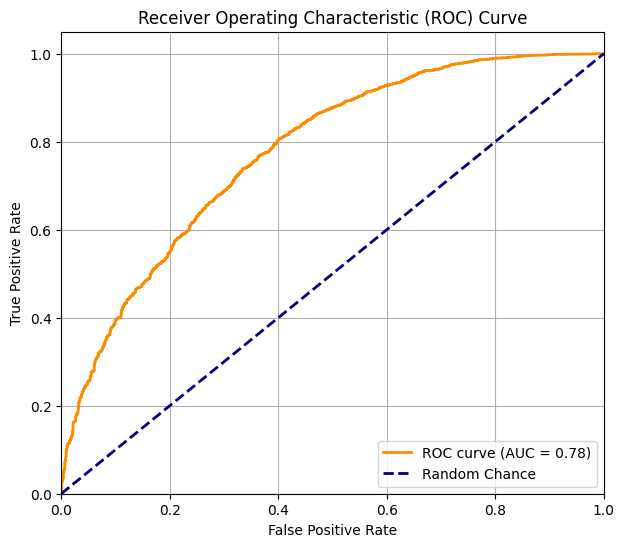

In [56]:
lr4 = LogisticRegression(max_iter=1000 , class_weight='balanced', random_state=42 , n_jobs=-1)
lr4.fit(xtrain1,ytrain1)
lr4_train_metrics , lr4_test_metrics = evaluate_classification_model_binary(lr4 , xtrain1 , ytrain1 , xtest1 , ytest1)

xgb model for binary data

In [ ]:
# xgb_model = XGBClassifier(
#     objective='binary:logistic',  # Binary classification
#     eval_metric='logloss',
#     use_label_encoder=False,
#     random_state=42,
#     n_estimators=100,
#     learning_rate=0.1,
#     max_depth=5
# )

In [58]:
from pandas.core.common import random_state
from sklearn.utils import class_weight
import numpy as np

classes = np.unique(ytrain1)
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=classes, y=ytrain1)
weight_dict = dict(zip(classes, class_weights))
sample_weights = np.array([weight_dict[c] for c in ytrain1])

xgb2 = XGBClassifier(random_state=42 , n_jobs = -1)
xgb2.fit(xtrain1, ytrain1, sample_weight=sample_weights)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Training Metrics:
Accuracy: 0.7941
Precision: 0.9534
Recall: 0.7980
F1 Score: 0.8688
ROC AUC: 0.8736

Testing Metrics:
Accuracy: 0.7570
Precision: 0.9271
Recall: 0.7767
F1 Score: 0.8453
ROC AUC: 0.7833

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.33      0.64      0.43      1250
           1       0.93      0.78      0.85      7335

    accuracy                           0.76      8585
   macro avg       0.63      0.71      0.64      8585
weighted avg       0.84      0.76      0.79      8585



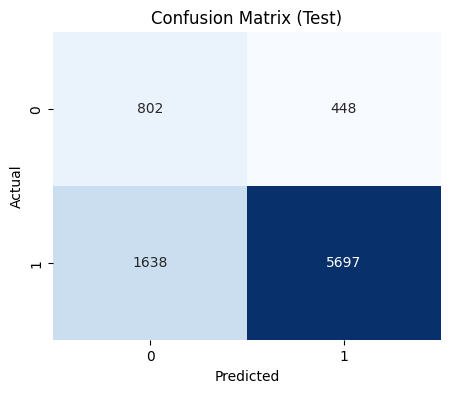

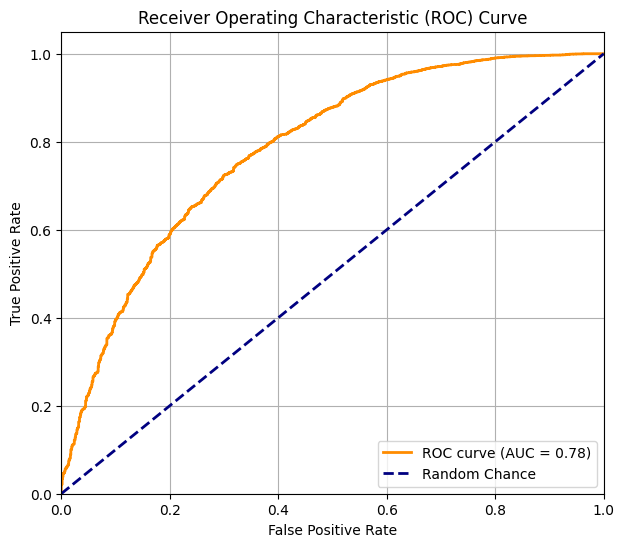

{'train_metrics': (0.7940826258024436,
  0.9534012559040156,
  0.7980126933155607,
  0.8688137996998632,
  0.8735801403116829),
 'test_metrics': (0.7570180547466512,
  0.9270951993490643,
  0.7766871165644171,
  0.8452522255192878,
  0.7833485480572597)}

In [59]:
evaluate_classification_model_binary(xgb2 , xtrain1 , ytrain1 , xtest1 , ytest1)

In [60]:
# saving the lr4 model 

import joblib 
joblib.dump(lr4 , "../artifacts/models/lr4_binary_classification_model.joblib")

['../artifacts/models/lr4_binary_classification_model.joblib']